In [1]:
import numpy as np
import matplotlib.pyplot as plt
from rna_gpf.utils import load_phenotype_and_metric_from_file
import seaborn as sns
import json
from scipy.stats.stats import pearsonr, linregress

/tmp/ipykernel_14191/3630856617.py:6: DeprecationWarning: Please import `pearsonr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.stats.stats import pearsonr, linregress
/tmp/ipykernel_14191/3630856617.py:6: DeprecationWarning: Please import `linregress` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.stats.stats import pearsonr, linregress


# phenotype frequency correlation

In [2]:
vienna_dir = "../output/gp_map_viennaRNA/"
seq_free_dir = "../output/gp_map_04/"

unfolded = "............"

In [3]:
ph_dist_vie = dict(zip(*load_phenotype_and_metric_from_file(vienna_dir + "phenotype_distribution.txt")))
ph_dist_seq = dict(zip(*load_phenotype_and_metric_from_file(seq_free_dir + "phenotype_distribution.txt")))

Text(0, 0.5, 'ph. freq.\nSequence-free method (ph based unf.)')

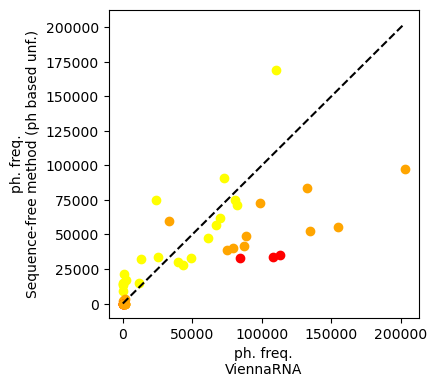

In [4]:
fig, ax = plt.subplots(figsize=(4, 4))


max_ = 0

colors = ["yellow", "orange", "red"]

for ph in ph_dist_vie:
    if ph != unfolded:
        bps = sum([1 for s in ph if s == "("])
        x, y = ph_dist_vie[ph], ph_dist_seq[ph]
        ax.scatter(x, y, color=colors[bps-2])
        if x > max_:
            max_ = x
        if y > max_:
            max_ = y
        
    
ax.plot([0, max_], [0, max_], color="black", linestyle="--")
ax.set_xlabel("ph. freq.\nViennaRNA")
ax.set_ylabel("ph. freq.\nSequence-free method (ph based unf.)")


### mfe calc

In [5]:

def plot_energy_boxplots(ph_to_mfes, output_path=None, figsize_per_box=0.35,
                          min_width=8, rotation=90, horizontal=False,
                          title="MFE energy distribution per phenotype",
                          ylabel="Energy"):
    """
    ph_to_mfes: dict {phenotype: list of energies (floats)}
    output_path: if given, saves the figure there (png/pdf/etc, by extension)
    figsize_per_box: how much figure width (or height, if horizontal) to
        allocate per phenotype, so the figure scales with how many
        phenotypes there are instead of getting cramped.
    rotation: x-tick label rotation in degrees (vertical layout only).
    horizontal: if True, draws horizontal boxplots with phenotype labels
        on the y-axis instead -- often more readable when there are many
        phenotypes and/or long dot-bracket strings, since labels read
        left-to-right without rotation.
 
    Returns (fig, ax).
    """
    # order phenotypes by descending mean energy
    means = {ph: float(np.mean(vals)) for ph, vals in ph_to_mfes.items()}
    ordered = sorted(means, key=means.get, reverse=True)
    data = [ph_to_mfes[ph] for ph in ordered]
    n = len(ordered)
    positions = list(range(1, n + 1))
 
    if horizontal:
        fig_h = max(6, figsize_per_box * n)
        fig, ax = plt.subplots(figsize=(8, fig_h))
        ax.boxplot(data, positions=positions, vert=False)
        ax.set_yticks(positions)
        ax.set_yticklabels(ordered, fontsize=8, family="monospace")
        ax.invert_yaxis()  # highest mean energy at the top
        ax.set_xlabel(ylabel)
        ax.set_ylabel("Phenotype")
    else:
        fig_w = max(min_width, figsize_per_box * n)
        fig, ax = plt.subplots(figsize=(fig_w, 6))
        ax.boxplot(data, positions=positions)
        ax.set_xticks(positions)
        ax.set_xticklabels(ordered, rotation=rotation,
                            ha="center" if rotation == 90 else "right",
                            fontsize=8, family="monospace")
        ax.set_ylabel(ylabel)
        ax.set_xlabel("Phenotype")
 
    ax.set_title(title)
    fig.tight_layout()
 
    if output_path:
        fig.savefig(output_path, dpi=150)
        print(f"Saved figure to {output_path}")
 
    return fig, ax
 

In [6]:
mfes_file = "../output/gp_map_viennaRNA/phenotype_mfes.txt"

In [7]:
ph_to_mfes = {}

with open(mfes_file, "r") as f:
    for i, line_ in enumerate(f):
        line = line_.strip().split(" ")
        ph_to_mfes[line[0]] = [float(mfe) for mfe in line[2:]]

(<Figure size 1610x600 with 1 Axes>,
 <Axes: title={'center': 'MFE energy distribution per phenotype'}, xlabel='Phenotype', ylabel='Energy'>)

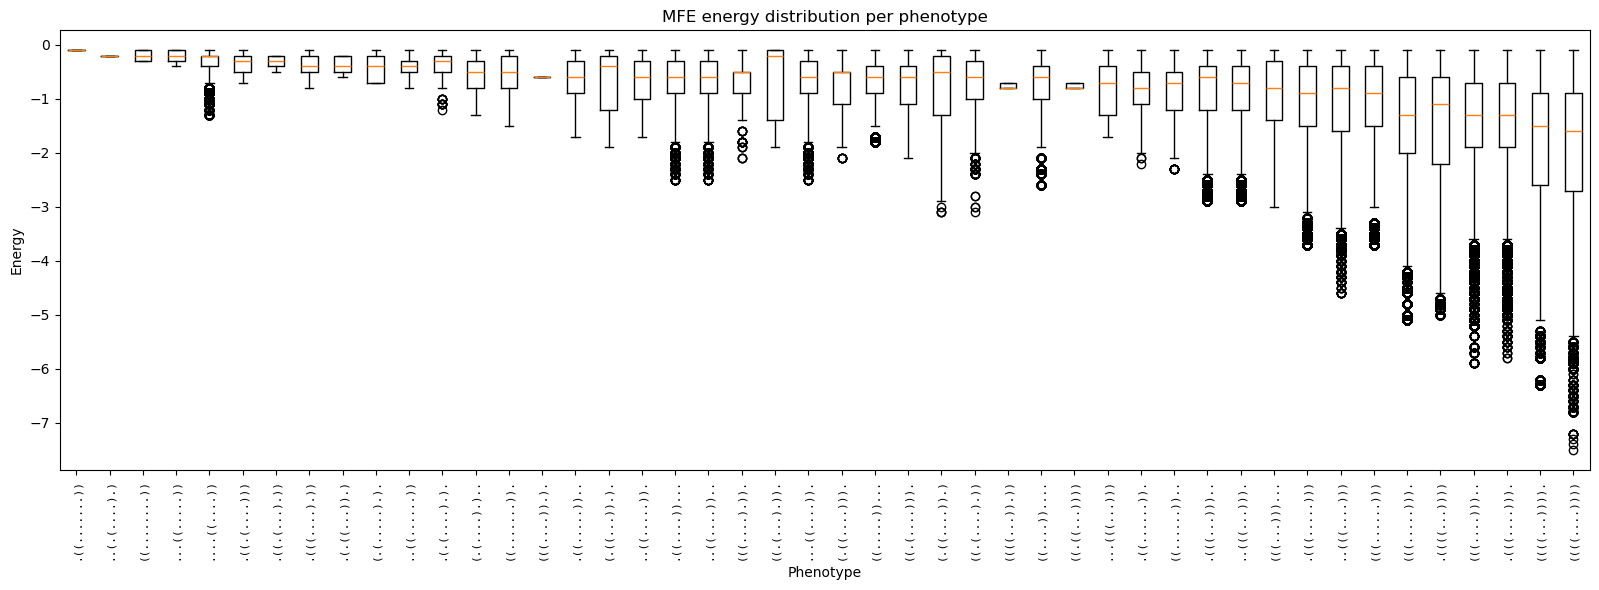

In [8]:
plot_energy_boxplots(ph_to_mfes, output_path=None, figsize_per_box=0.35,
                          min_width=8, rotation=90, horizontal=False,
                          title="MFE energy distribution per phenotype",
                          ylabel="Energy")
    

## prediction validation

In [9]:
# with open('../output/gp_map_viennaRNA/per_ph_match_and_unfolded_counts_ph_based_unf.json') as json_file:
with open('../output/gp_map_viennaRNA/per_ph_match_and_unfolded_counts.json') as json_file:
    data = json.load(json_file)

In [10]:
gt_count = 4**12

frac_sum = 0
for stat in data:
    frac = data[stat] / gt_count
    frac_sum += frac
    print(stat, frac)

print(frac_sum)


both_unf 0.7899185419082642
que_unf 0.11424142122268677
ref_unf 0.08165359497070312
folded_mismatch 0.0035779476165771484
folded_match 0.010608494281768799
1.0


In [11]:
all_ref_folded = data["folded_match"] + data["folded_mismatch"] + data["que_unf"]

ref_folded_pred_frac = data["folded_match"] / all_ref_folded
ref_folded_unfpred_frac = data["que_unf"] / all_ref_folded
ref_folded_wrongpred_frac = data["folded_mismatch"] / all_ref_folded


print(ref_folded_pred_frac, ref_folded_unfpred_frac, ref_folded_wrongpred_frac)

0.08260274697377129 0.8895376629837998 0.02785959004242893


In [12]:
all_que_folded = data["folded_match"] + data["folded_mismatch"] + data["ref_unf"]
que_folded_pred_frac = data["folded_match"] / all_que_folded

que_folded_pred_frac



0.11068958890597781

## navigability per fl comp 

In [13]:
navigs_seq_free = []
phs_seq_free = []

with open('../output/gp_map_04/navigability_per_fl_pop1000000.txt', "r") as f:
    for line_ in f:
        navigs_seq_free.append(float(line_.strip().split(" ")[1]))
        phs_seq_free.append(line_.strip().split(" ")[0])

navigs_vienna = []
phs_vienna = []

with open('../output/gp_map_04/navigability_per_fl_pop1000000_vienna_RNA_gp_map.txt', "r") as f:
    for line_ in f:
        navigs_vienna.append(float(line_.strip().split(" ")[1]))
        phs_vienna.append(line_.strip().split(" ")[0])

0.6696107841889922 2.2236886275592924e-27


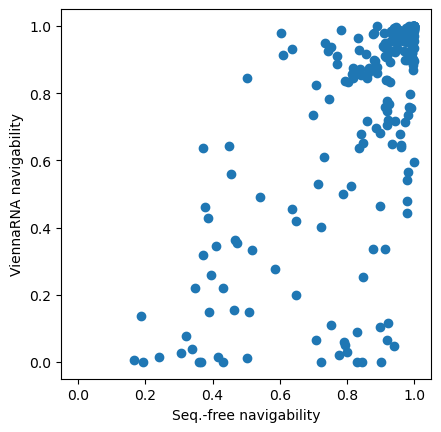

In [14]:
fig, ax = plt.subplots()

ax.set_xlim(-0.05,1.05)
ax.set_ylim(-0.05,1.05)
ax.set_box_aspect(1)
ax.set_xlabel("Seq.-free navigability")
ax.set_ylabel("ViennaRNA navigability")
ax.scatter(navigs_seq_free, navigs_vienna)
r, p = pearsonr(navigs_seq_free, navigs_vienna)
print(r, p)

In [15]:
np.mean(navigs_seq_free), np.mean(navigs_vienna)

(np.float64(0.82498), np.float64(0.6972700000000001))

## Unfolded frac reviewer reply

PearsonRResult(statistic=np.float64(0.9561565118462438), pvalue=np.float64(1.5330766165944277e-05)) PearsonRResult(statistic=np.float64(0.9466652202267268), pvalue=np.float64(3.318558956411828e-05)) PearsonRResult(statistic=np.float64(0.9804605092442925), pvalue=np.float64(6.2288993956697e-07))
PearsonRResult(statistic=np.float64(0.9868221087161674), pvalue=np.float64(1.2986059754342237e-07)) PearsonRResult(statistic=np.float64(0.9854272471003604), pvalue=np.float64(1.9387841800884984e-07)) PearsonRResult(statistic=np.float64(0.9872433035954223), pvalue=np.float64(1.1409514126664691e-07))


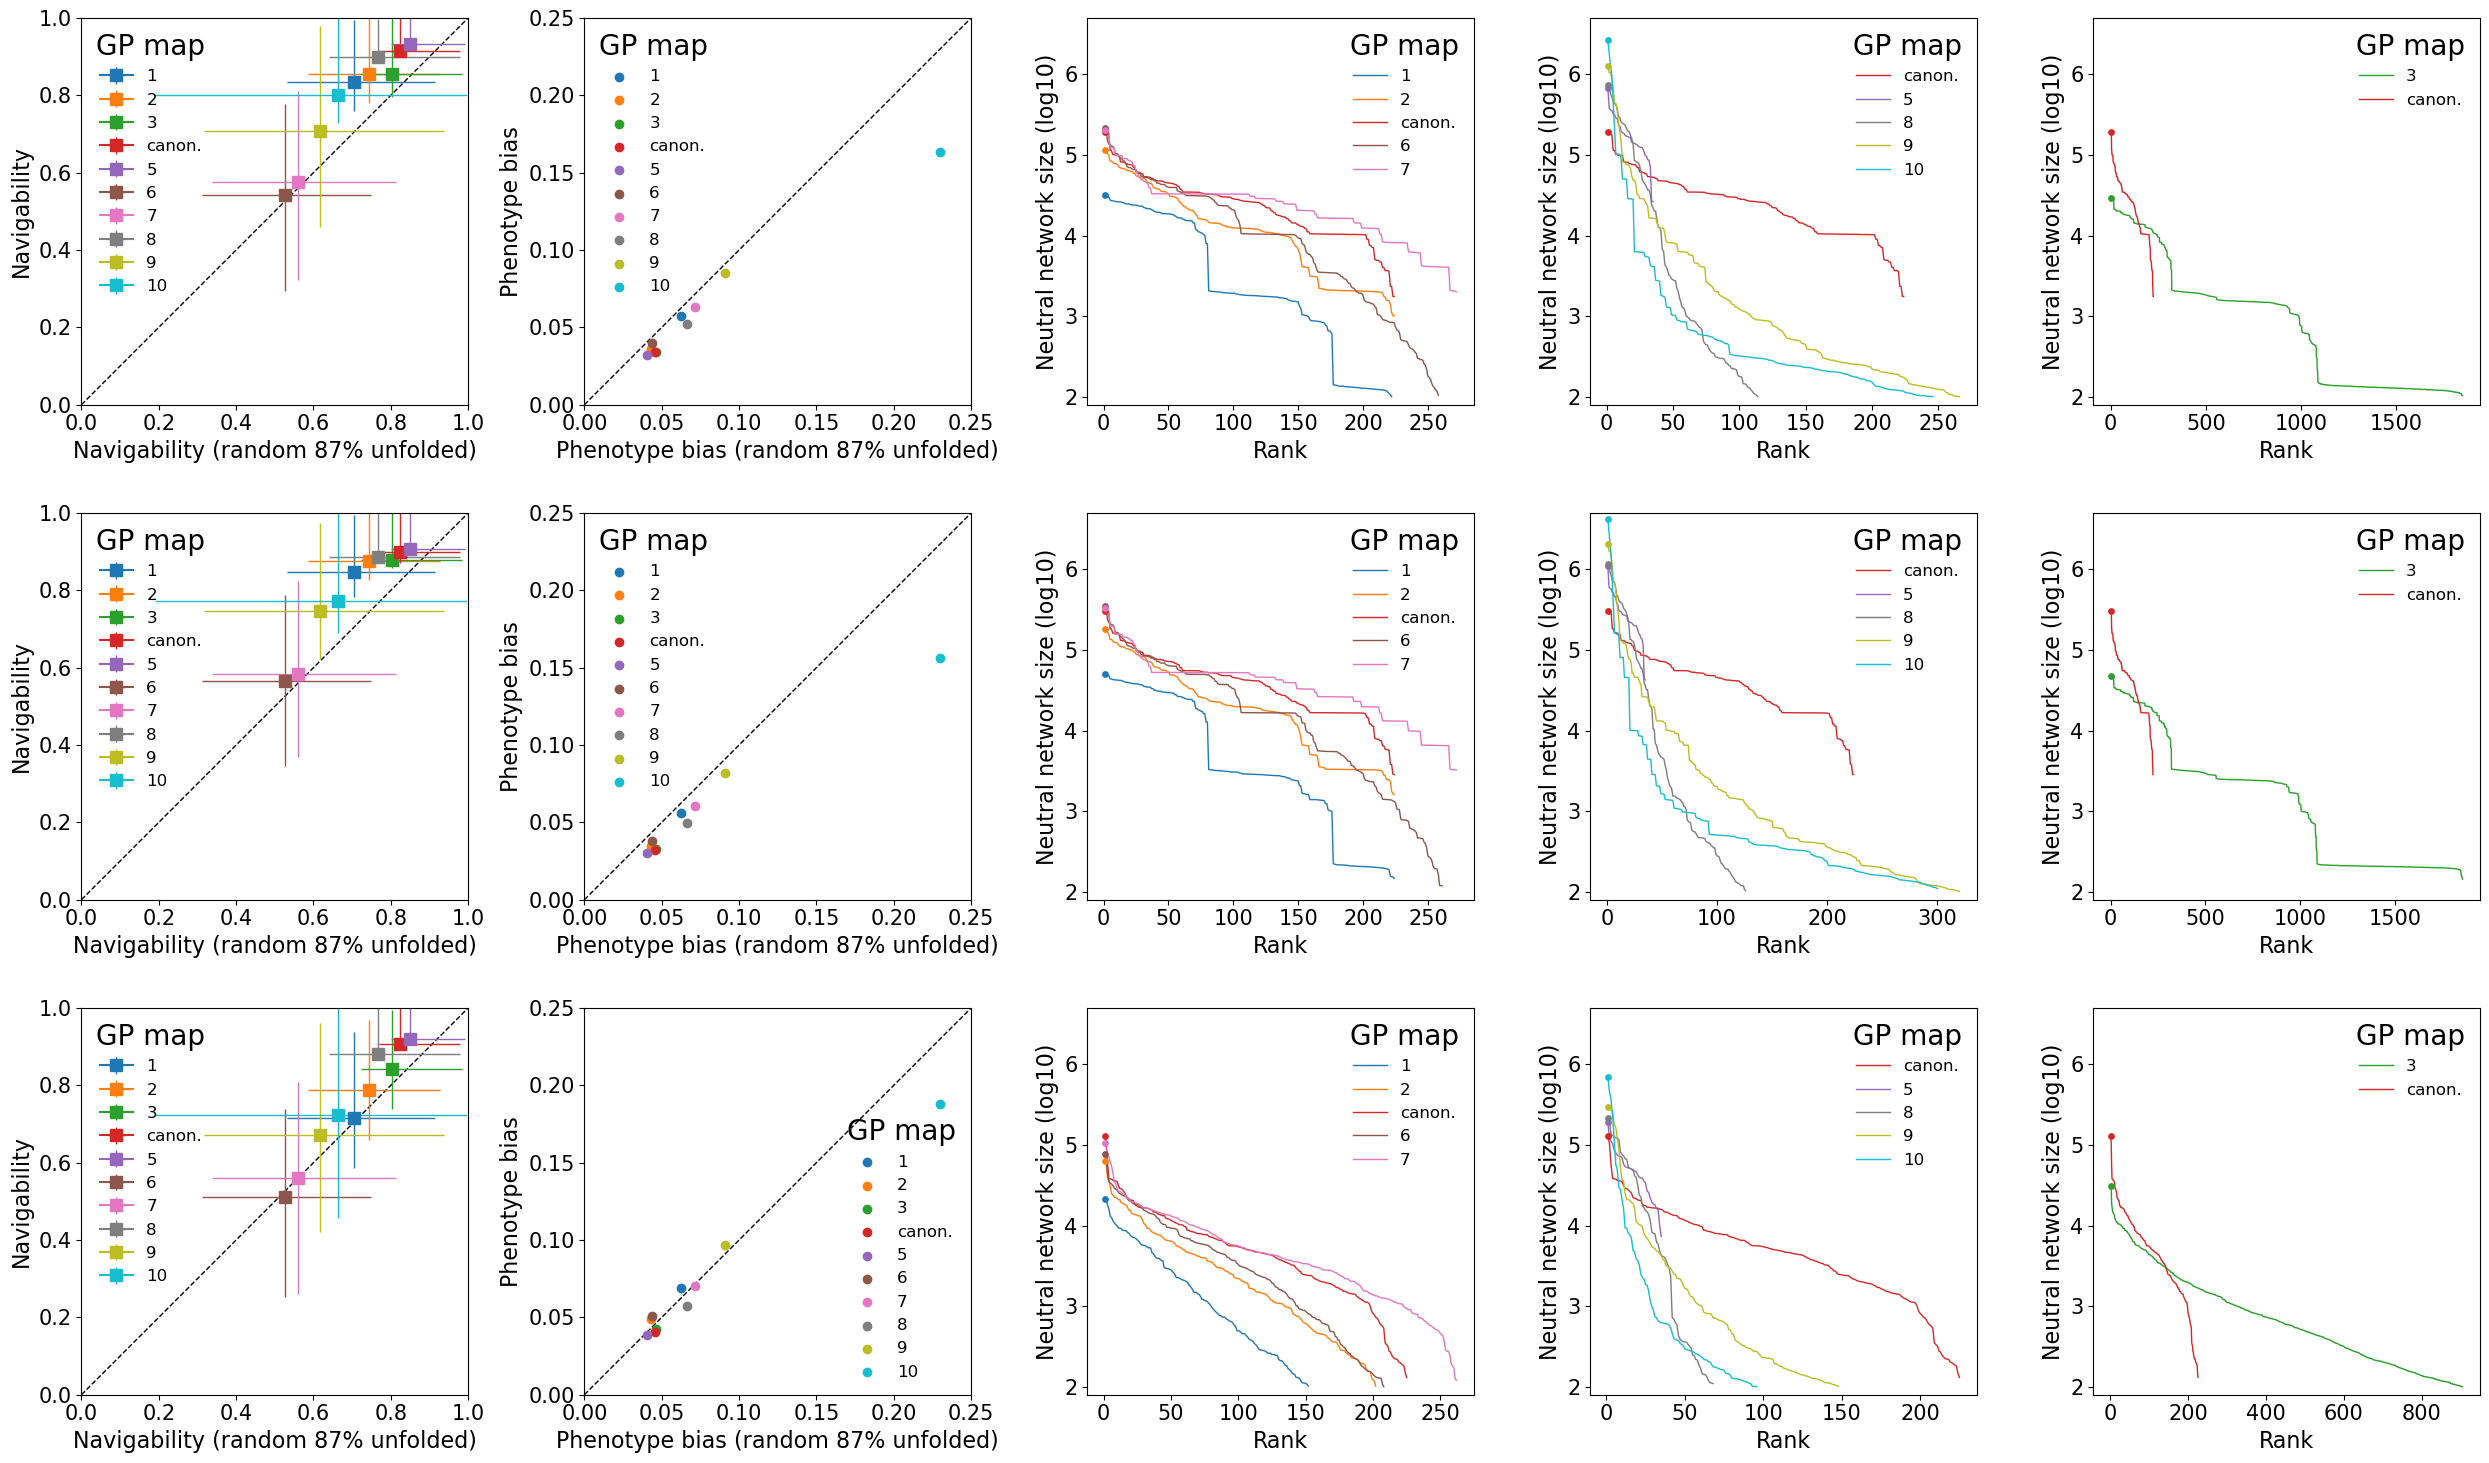

In [19]:
gp_map_ids = ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10"]
labels = ["1", "2", "3", "canon.", "5", "6", "7", "8", "9", "10"]

cat1 = ["01", "02", "06", "07", "04"]
cat2 = ["05", "08", "09", "10", "04"]
cat3 = ["03", "04"]

fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(25, 15))

fs = 16

navig_means1 = []
navig_means2 = []
navig_means3 = []
navig_means4 = []

ph_biases1 = []
ph_biases2 = []
ph_biases3 = []
ph_biases4 = []

for i, (label, id_) in enumerate(zip(labels, gp_map_ids), start=1):
    # navigability files
    f1 = f"../output/gp_map_{id_}/navigability_per_fl_pop1000000.txt"
    phs1, navigs1 = load_phenotype_and_metric_from_file(f1)

    f2 = f"../output/gp_map_{id_}/navigability_per_fl_pop1000000_unfolded8388608.txt"
    phs2, navigs2 = load_phenotype_and_metric_from_file(f2)

    f3 = f"../output/gp_map_{id_}/navigability_per_fl_pop1000000_unfolded3355443.txt"
    phs3, navigs3 = load_phenotype_and_metric_from_file(f3)

    f4 = f"../output/gp_map_{id_}/navigability_per_fl_pop1000000_diffu_unfolded.txt"
    phs4, navigs4 = load_phenotype_and_metric_from_file(f4)


    ax1 = axes[0][0]
    ax2 = axes[1][0]
    ax3 = axes[2][0]

    nmean1 = np.mean(navigs1)
    nmean2 = np.mean(navigs2)
    nmean3 = np.mean(navigs3)
    nmean4 = np.mean(navigs4)

    navig_means1.append(nmean1)
    navig_means2.append(nmean2)
    navig_means3.append(nmean3)
    navig_means4.append(nmean4)

    xq1 = [max(0, nmean1-np.percentile(navigs1, q=25))]
    xq2 = [max(0, np.percentile(navigs1, q=75)-nmean1)]

    for ax, navigs in zip(axes[:, 0], [navigs2, navigs3, navigs4]):
        nmean2 = np.mean(navigs) 

        # ax.scatter(nmean1, nmean2, label=id_)
        yq1 = [max(0, nmean2-np.percentile(navigs, q=25))]
        yq2 = [max(0, np.percentile(navigs, q=75)-nmean2)]

        ax.errorbar(nmean1, nmean2, xerr=(xq1, xq2), yerr=(yq1, yq2), elinewidth=1, marker="s", markersize=8, label=label)

        ax.set_ylabel("Navigability", fontsize=fs)


    # phenotype distribution files
    p1 = f"../output/gp_map_{id_}/phenotype_distribution.txt"
    phs1_, dist1 = load_phenotype_and_metric_from_file(p1)

    p2 = f"../output/gp_map_{id_}/phenotype_distribution_unfolded8388608.txt"
    phs2_, dist2 = load_phenotype_and_metric_from_file(p2)

    p3 = f"../output/gp_map_{id_}/phenotype_distribution_unfolded3355443.txt"
    phs3_, dist3 = load_phenotype_and_metric_from_file(p3)

    p4 = f"../output/gp_map_{id_}/phenotype_distribution_diffu_unfolded.txt"
    phs4_, dist4 = load_phenotype_and_metric_from_file(p4)


    ax1_ = axes[0][1]
    ax2_ = axes[1][1]
    ax3_ = axes[2][1]

    d1_sort = np.log10([v for v in sorted(dist1) if v > 0])
    d2_sort = np.log10([v for v in sorted(dist2) if v > 0])
    d3_sort = np.log10([v for v in sorted(dist3) if v > 0])
    d4_sort = np.log10([v for v in sorted(dist4) if v > 0])

    x1 = np.arange(stop=len(d1_sort)+1, start=1)
    x2 = np.arange(stop=len(d2_sort)+1, start=1)
    x3 = np.arange(stop=len(d3_sort)+1, start=1)
    x4 = np.arange(stop=len(d4_sort)+1, start=1)

    slope1, intercept1, r_valu1, p_value1, std_err1 = linregress(x1, d1_sort)
    slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x2, d2_sort)
    slope3, intercept3, r_value3, p_value3, std_err3 = linregress(x3, d3_sort)
    slope4, intercept4, r_valu4, p_value4, std_err4 = linregress(x4, d4_sort)

    ph_biases1.append(slope1)
    ph_biases2.append(slope2)
    ph_biases3.append(slope3)
    ph_biases4.append(slope4)

    ax1_.scatter(slope1, slope2, label=label)
    ax2_.scatter(slope1, slope3, label=label)
    ax3_.scatter(slope1, slope4, label=label)

    ax1_.set_ylabel("Phenotype bias", fontsize=fs)
    ax2_.set_ylabel("Phenotype bias", fontsize=fs)
    ax3_.set_ylabel("Phenotype bias", fontsize=fs)


    # phenotype distribution files
    n1 = f"../output/gp_map_{id_}/neutral_component_sizes.txt"
    nc1, ncsize1 = load_phenotype_and_metric_from_file(n1)

    n2 = f"../output/gp_map_{id_}/neutral_component_sizes_unfolded8388608.txt"
    nc2, ncsize2 = load_phenotype_and_metric_from_file(n2)

    n3 = f"../output/gp_map_{id_}/neutral_component_sizes_unfolded3355443.txt"
    nc3, ncsize3 = load_phenotype_and_metric_from_file(n3)

    n4 = f"../output/gp_map_{id_}/neutral_component_sizes_diffu_unfolded.txt"
    nc4, ncsize4 = load_phenotype_and_metric_from_file(n4)

    size_cut = 0
    n1_sort = np.log10([v for v in sorted(ncsize1)[::-1] if v > size_cut])
    n2_sort = np.log10([v for v in sorted(ncsize2)[::-1] if v > size_cut])
    n3_sort = np.log10([v for v in sorted(ncsize3)[::-1] if v > size_cut])
    n4_sort = np.log10([v for v in sorted(ncsize4)[::-1] if v > size_cut])

    x1 = np.arange(stop=len(n1_sort)+1, start=1)
    x2 = np.arange(stop=len(n2_sort)+1, start=1)
    x3 = np.arange(stop=len(n3_sort)+1, start=1)
    x4 = np.arange(stop=len(n4_sort)+1, start=1)

    s=15
    if id_ in cat1:
        axes[0][2].plot(x2, n2_sort, label=label, linewidth=1, color=f"C{i-1}")
        axes[0][2].scatter(x2[0], n2_sort[0], color=f"C{i-1}", zorder=15, s=s)
        axes[1][2].plot(x3, n3_sort, label=label, linewidth=1, color=f"C{i-1}")
        axes[1][2].scatter(x3[0], n3_sort[0], color=f"C{i-1}", zorder=15, s=s)
        axes[2][2].plot(x4, n4_sort, label=label, linewidth=1, color=f"C{i-1}")
        axes[2][2].scatter(x4[0], n4_sort[0], color=f"C{i-1}", zorder=15, s=s)
    
    if id_ in cat2:
        axes[0][3].plot(x2, n2_sort, label=label, linewidth=1, color=f"C{i-1}")
        axes[0][3].scatter(x2[0], n2_sort[0], color=f"C{i-1}", zorder=15, s=s)
        axes[1][3].plot(x3, n3_sort, label=label, linewidth=1, color=f"C{i-1}")
        axes[1][3].scatter(x3[0], n3_sort[0], color=f"C{i-1}", zorder=15, s=s)
        axes[2][3].plot(x4, n4_sort, label=label, linewidth=1, color=f"C{i-1}")
        axes[2][3].scatter(x4[0], n4_sort[0], color=f"C{i-1}", zorder=15, s=s)
    
    if id_ in cat3:
        axes[0][4].plot(x2, n2_sort, label=label, linewidth=1, color=f"C{i-1}")
        axes[0][4].scatter(x2[0], n2_sort[0], color=f"C{i-1}", zorder=15, s=s)
        axes[1][4].plot(x3, n3_sort, label=label, linewidth=1, color=f"C{i-1}")
        axes[1][4].scatter(x3[0], n3_sort[0], color=f"C{i-1}", zorder=15, s=s)
        axes[2][4].plot(x4, n4_sort, label=label, linewidth=1, color=f"C{i-1}")
        axes[2][4].scatter(x4[0], n4_sort[0], color=f"C{i-1}", zorder=15, s=s)

    # ax1_.scatter(max(n1_sort), max(n2_sort), label=id_)
    # ax2_.scatter(max(n1_sort), max(n3_sort), label=id_)
    # ax3_.scatter(max(n1_sort), max(n4_sort), label=id_)

    # ax1_.scatter(len(n1_sort), len(n2_sort), label=id_)
    # ax2_.scatter(len(n1_sort), len(n3_sort), label=id_)
    # ax3_.scatter(len(n1_sort), len(n4_sort), label=id_)
    

legend_fs = 12
for ax in axes[:,0]:
    ax.legend(fancybox=False, frameon=False, fontsize=legend_fs, title="GP map")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.plot([0,1], [0,1], linestyle="--", linewidth=1, zorder=-10, color="black")
    ax.set_box_aspect(1)

    ax.set_xlabel("Navigability (random 87% unfolded)", fontsize=fs)

    ax.tick_params(axis='both', which='major', labelsize=15)
    ax.tick_params(axis='both', which='minor', labelsize=15)

for ax in axes[:,1]:
    ax.legend(fancybox=False, frameon=False, fontsize=legend_fs, title="GP map")
    ax.set_xlim(0, .25)
    ax.set_ylim(0, .25)
    ax.set_box_aspect(1)
    ax.plot([0,.25], [0,.25], linestyle="--", linewidth=1, zorder=-10, color="black")

    ax.set_xlabel("Phenotype bias (random 87% unfolded)", fontsize=fs)

    ax.tick_params(axis='both', which='major', labelsize=15)
    ax.tick_params(axis='both', which='minor', labelsize=15)

for ax in axes[:,2:].flatten():
    ax.legend(fancybox=False, frameon=False, fontsize=legend_fs, title="GP map")
    ax.set_box_aspect(1)
    ax.set_xlabel("Rank", fontsize=fs)
    ax.set_ylabel("Neutral network size (log10)", fontsize=fs)

    ax.set_ylim(1.9, 6.7)
    ax.tick_params(axis='both', which='major', labelsize=15)
    ax.tick_params(axis='both', which='minor', labelsize=15)

print(pearsonr(navig_means1, navig_means2), pearsonr(navig_means1, navig_means3), pearsonr(navig_means1, navig_means4))
print(pearsonr(ph_biases1, ph_biases2), pearsonr(ph_biases1, ph_biases3), pearsonr(ph_biases1, ph_biases4))

plt.tight_layout()
plt.rcParams['legend.title_fontsize'] = 20
# plt.savefig("unfolded_approach_check.pdf", format="pdf", dpi=300)